In [179]:
import yfinance as yf
import pandas as pd

# choose stock ticker
ticker = "TSLA"

# download data
data = yf.download(ticker, start="2010-01-01", end="2026-03-27")

print(data.head())
print(data.tail())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          TSLA      TSLA      TSLA      TSLA       TSLA
Date                                                         
2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500
Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2026-03-20  367.959991  379.890015  364.459991  379.850006  78628600
2026-03-23  380.850006  385.329987  372.730011  373.089996  74606000
2026-03-24  383.029999  387.480011  376.309998  376.559998  60004900
2026-03-25  385.950012  396.230011  385.010010  389.989990  55157300
2026-03-26  372.10998

In [180]:
# calculate daily returns
data["Return"] = data["Close"].pct_change()


# 5-day momentum
data["Momentum_5"] = data["Close"] / data["Close"].shift(5) - 1

# 10-day moving average
data["MA_10"] = data["Close"].rolling(window=10).mean()

# 10-day volatility
data["Volatility_10"] = data["Return"].rolling(window=10).std()


data['Momentum_10'] = data['Close'] / data['Close'].shift(10) - 1

data['MA_20'] = data['Close'].rolling(window=20).mean()

data['Volatility_20'] = data['Return'].rolling(window=20).std()


data = data.dropna()


In [181]:
# create future return (5 days ahead)
data["Target"] = data["Close"].shift(-5) / data["Close"] - 1

data["Target_Class"] = (data["Target"] > 0).astype(int)

data = data.dropna()


In [182]:
features = ["Return", "Momentum_5", "MA_10", "Volatility_10"]

X = data[features]
y = data["Target_Class"]

In [183]:
# split manually (no shuffle!)
split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [184]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=4)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [185]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5146124523506989


I don't understand this here,

shift Target_Class to avoid lookahead bias

data_test["Target_Class"] = data_test["Target_Class"].shift(1)

strategy return

data_test["Strategy_Return"] = data_test["Target_Class"] * data_test["Return"]

# Why are we shifting, how does it affect. How are we looking ahead.

🔹 Why shift(1)?
shift(1)

Means:

today's prediction → tomorrow's trade

Prevents cheating.

# but still I don't get it intuitivly

In [186]:
# add predictions to dataframe
data_test = data.iloc[split:].copy()

data_test["Prediction"] = y_pred

data_test["Signal"] = data_test["Prediction"]

# shift signal to avoid lookahead bias
data_test["Signal"] = data_test["Signal"].shift(1)

# strategy return
data_test["Strategy_Return"] = data_test["Signal"] * data_test["Return"]

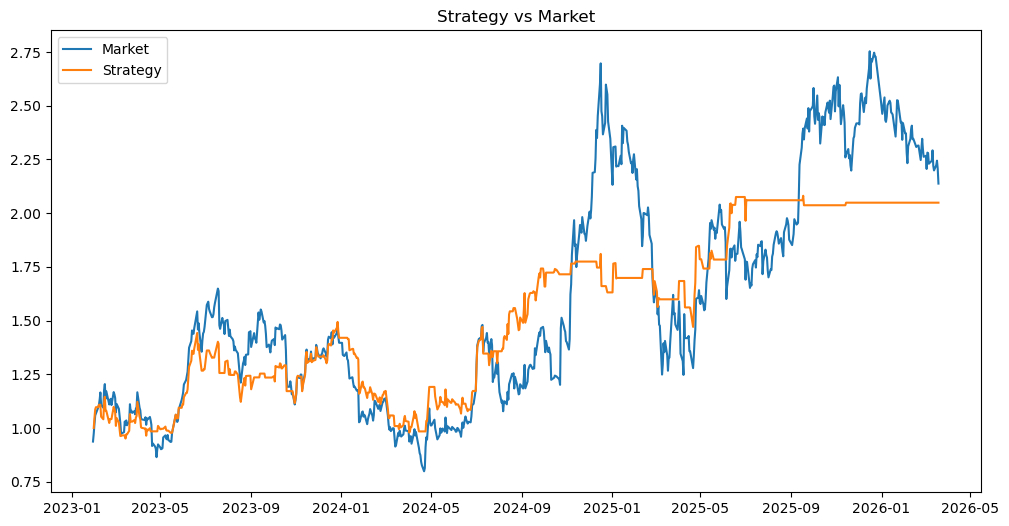

In [187]:
# cumulative returns
data_test["Cumulative_Market"] = (1 + data_test["Return"]).cumprod()
data_test["Cumulative_Strategy"] = (1 + data_test["Strategy_Return"]).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data_test["Cumulative_Market"], label="Market")
plt.plot(data_test["Cumulative_Strategy"], label="Strategy")
plt.legend()
plt.title("Strategy vs Market")
plt.show()

In [190]:
total_return = data_test["Cumulative_Strategy"].iloc[-1]
sharpe = data_test["Strategy_Return"].mean() / data_test["Strategy_Return"].std()
market_return = data_test["Cumulative_Market"].iloc[-1]
print("Total Return:", total_return)
print("Sharpe Ratio:", sharpe)
print("Market Return:", market_return)

Total Return: 2.0488646845245984
Sharpe Ratio: 0.052246944489043316
Market Return: 2.1377178237243597
